# Model Evaluation and ROC Curves

In this notebook, we'll evaluate the performance of our trained models and analyze ROC curves.

Train docs: 6,337,  Test docs: 2,477
Labels: ['earn', 'acq', 'crude', 'interest', 'money-fx', 'trade', 'grain', 'corn', 'dlr', 'money-supply']


/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188:

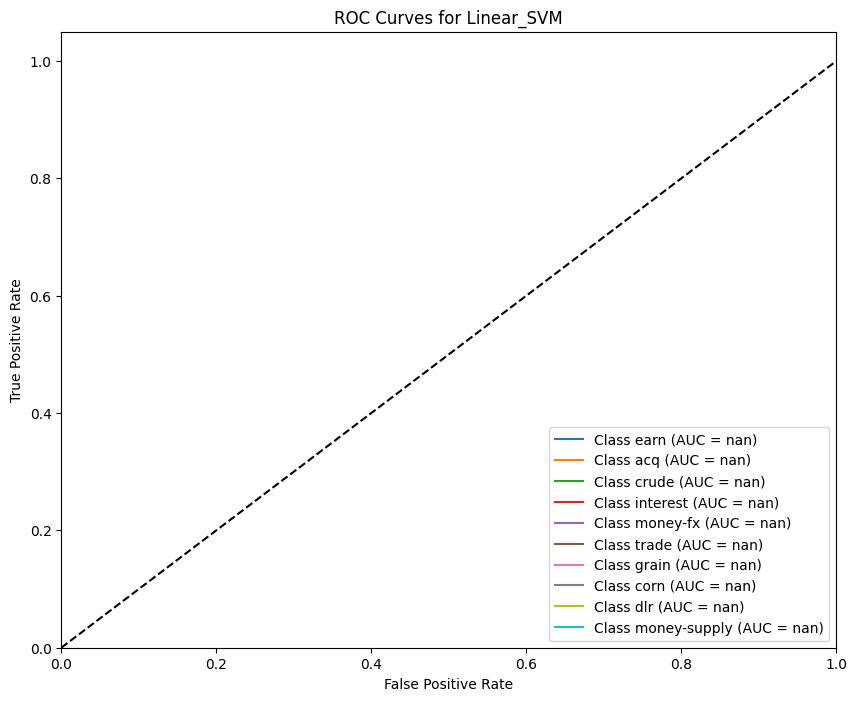

/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/marcmaceira/venv/reuters-rag-classifier/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1188:

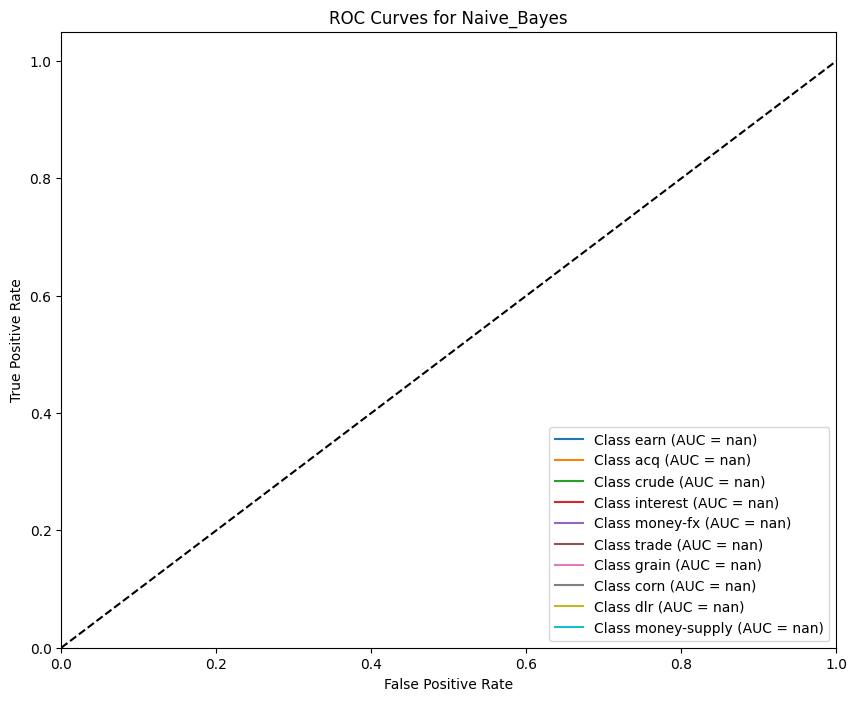

TypeError: Object of type ndarray is not JSON serializable

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import json
import os
from src.dataset import load_data
import joblib
from sklearn.base import is_classifier

# Load dataset
N_CLASSES = 10
X_train, y_train, X_test, y_test, label_names = load_data(N_CLASSES)
print(f'Train docs: {len(X_train):,},  Test docs: {len(X_test):,}')
print('Labels:', label_names)

input_folder = 'models/num_classes_0010'

# Load model results
model_results = {}
for model_dir in os.listdir(input_folder):
    if os.path.isdir(os.path.join(input_folder, model_dir)):
        model_path = os.path.join(input_folder, model_dir, 'model.joblib')
        metrics_path = os.path.join(input_folder, model_dir, 'metrics.joblib')
        
        if os.path.exists(model_path) and os.path.exists(metrics_path):
            model = joblib.load(model_path)
            metrics = joblib.load(metrics_path)
            
            # Get predictions
            y_pred = model.predict(X_test)
            
            # Check if model supports probability predictions
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test)
            else:
                # For models without predict_proba, create binary predictions
                y_pred_proba = np.zeros((len(y_test), n_classes))
                for i in range(n_classes):
                    y_pred_proba[:, i] = (y_pred == i).astype(int)
            
            model_results[model_dir] = {
                'model': model,
                'metrics': metrics,
                'predictions': y_pred,
                'probabilities': y_pred_proba
            }

# Prepare data for ROC curves
n_classes = len(label_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# Create a separate plot for each model
for model_name, results in model_results.items():
    plt.figure(figsize=(10, 8))
    
    # Calculate ROC curve for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], results['probabilities'][:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Plot ROC curve for each class
        plt.plot(fpr[i], tpr[i], label=f'Class {label_names[i]} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves for {model_name}')
    plt.legend(loc="lower right")
    plt.show()

# Save evaluation results
evaluation_results = {
    'roc_curves': {
        model_name: {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc
        } for model_name, results in model_results.items()
    }
}

with open('results/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f)

In [6]:
# Analyze worst classified articles
def get_worst_classified_articles(model_name, n=5):
    errors_df = model_results[model_name]['errors']
    worst_indices = errors_df['idx'].values[:n]
    
    print(f"\nWorst classified articles for {model_name}:")
    for idx in worst_indices:
        print(f"\nArticle {idx}:")
        print(f"True label: {errors_df.loc[errors_df['idx'] == idx, 'true'].values[0]}")
        print(f"Predicted label: {errors_df.loc[errors_df['idx'] == idx, 'pred'].values[0]}")
        print(f"Text preview: {errors_df.loc[errors_df['idx'] == idx, 'preview'].values[0]}")

# Get worst classified articles for each model
for model_name in model_results.keys():
    get_worst_classified_articles(model_name)

# Save evaluation results
evaluation_results = {
    'roc_curves': {
        model_name: {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc
        } for model_name, results in model_results.items()
    }
}

with open('results/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f)